# 0.0 Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import recall_score, precision_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import joblib

# 0.1 Load dataset

In [3]:
df = pd.read_csv('../dataset/BankChurners.csv')
df

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.999910
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.999940
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.999980
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.999870
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.999980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462,0.000191,0.999810
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511,0.995270,0.004729
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,5409.0,0,5409.0,0.819,10291,60,0.818,0.000,0.997880,0.002118
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,5281.0,0,5281.0,0.535,8395,62,0.722,0.000,0.996710,0.003294


# 1.0 Descrição dos dados

## 1.1 Renomear colunas

In [4]:
df.columns = df.columns.str.lower()

## 1.2 Dimensões

In [5]:
df.shape

(10127, 23)

## 1.3 Tipos dos dados

In [6]:
df.dtypes

clientnum                                                                                                                               int64
attrition_flag                                                                                                                            str
customer_age                                                                                                                            int64
gender                                                                                                                                    str
dependent_count                                                                                                                         int64
education_level                                                                                                                           str
marital_status                                                                                                                            str
income

## 1.4 Checar NA

In [7]:
df.isna().sum()

clientnum                                                                                                                             0
attrition_flag                                                                                                                        0
customer_age                                                                                                                          0
gender                                                                                                                                0
dependent_count                                                                                                                       0
education_level                                                                                                                       0
marital_status                                                                                                                        0
income_category                                 

## 1.5 Remover colunas

In [8]:
df = df.drop(columns=['naive_bayes_classifier_attrition_flag_card_category_contacts_count_12_mon_dependent_count_education_level_months_inactive_12_mon_1', 'naive_bayes_classifier_attrition_flag_card_category_contacts_count_12_mon_dependent_count_education_level_months_inactive_12_mon_2'])

In [9]:
df

,clientnum,attrition_flag,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,...,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000


## 1.6 Estatística Descritiva

In [10]:
cat_attributes = df.select_dtypes(exclude=['int64', 'float64'])
num_attributes = df.select_dtypes(include=['int64', 'float64'])

### 1.6.1 Numericas

In [11]:
num_attributes.describe()

,clientnum,customer_age,dependent_count,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


## 1.6.2 Categoricas

#### 1.6.2.1 Gender

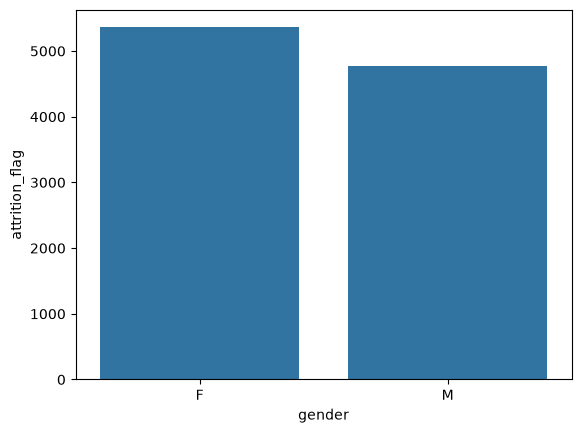

In [12]:
aux = cat_attributes[['gender', 'attrition_flag']].groupby('gender').count().reset_index()

sns.barplot(
    data=aux,
    x='gender',
    y='attrition_flag'
) 

plt.show()

#### 1.6.2.2 Education_level

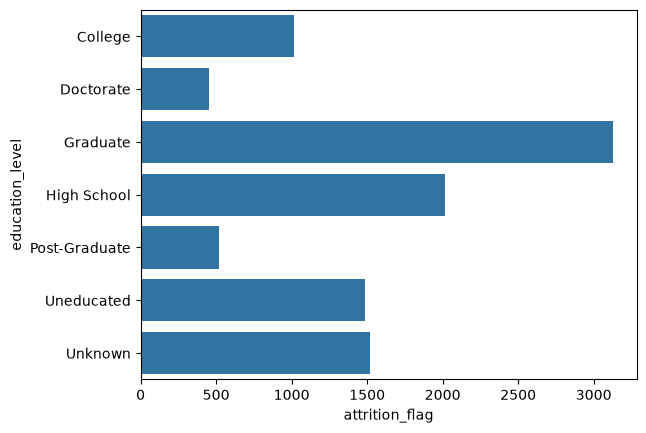

In [13]:
aux = cat_attributes[['education_level', 'attrition_flag']].groupby('education_level').count().reset_index()

sns.barplot(
    data=aux,
    x='attrition_flag',
    y='education_level'
) 

plt.show()

#### 1.6.2.3 Marital_status

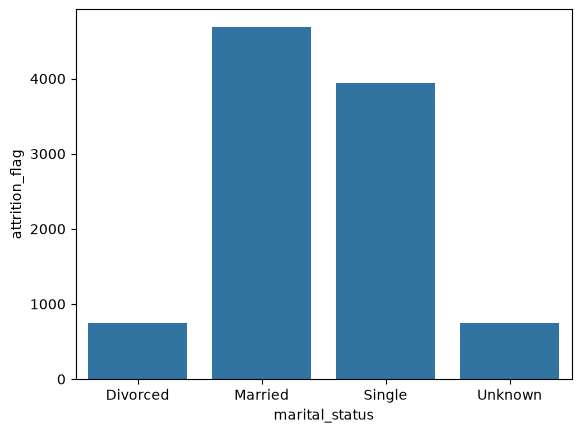

In [14]:
aux = cat_attributes[['marital_status', 'attrition_flag']].groupby('marital_status').count().reset_index()

sns.barplot(
    data=aux,
    x='marital_status',
    y='attrition_flag'
) 

plt.show()

#### 1.6.2.4 Income_category

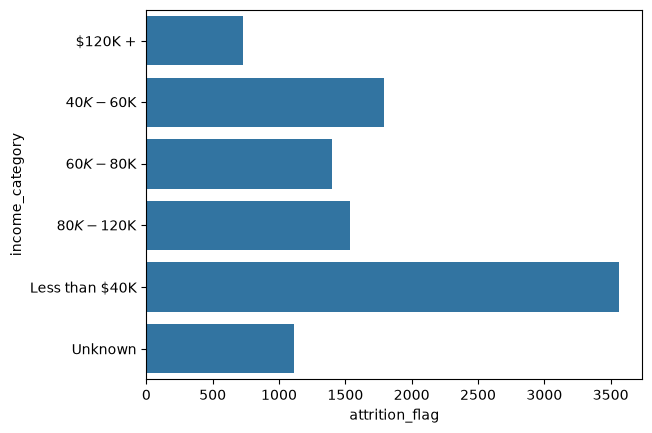

In [15]:
aux = cat_attributes[['income_category', 'attrition_flag']].groupby('income_category').count().reset_index()

sns.barplot(
    data=aux,
    x='attrition_flag',
    y='income_category'
) 

plt.show()

#### 1.6.2.5 Card_category

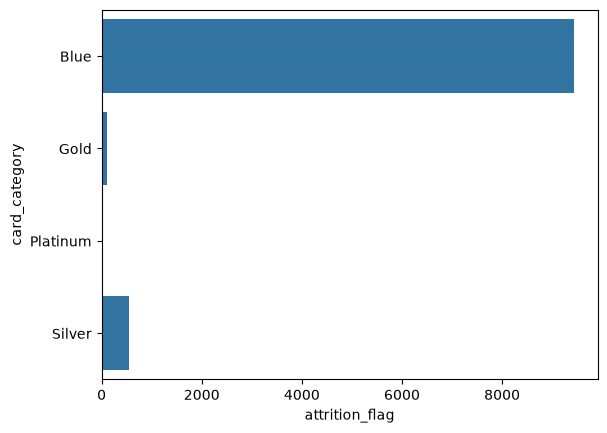

In [16]:
aux = cat_attributes[['card_category', 'attrition_flag']].groupby('card_category').count().reset_index()

sns.barplot(
    data=aux,
    x='attrition_flag',
    y='card_category'
) 

plt.show()

# 2.0 Divisão entre Train e Test

In [17]:
x = df.drop(columns=['clientnum', 'attrition_flag'])
y = df['attrition_flag']

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [19]:
variaveis_numericas = x.select_dtypes(include=['int64', 'float64']).columns
variaveis_categoricas = x.select_dtypes(exclude=['int64', 'float64']).columns

In [20]:
df.columns

Index(['clientnum', 'attrition_flag', 'customer_age', 'gender',
       'dependent_count', 'education_level', 'marital_status',
       'income_category', 'card_category', 'months_on_book',
       'total_relationship_count', 'months_inactive_12_mon',
       'contacts_count_12_mon', 'credit_limit', 'total_revolving_bal',
       'avg_open_to_buy', 'total_amt_chng_q4_q1', 'total_trans_amt',
       'total_trans_ct', 'total_ct_chng_q4_q1', 'avg_utilization_ratio'],
      dtype='str')

In [21]:
x_train.describe()

,customer_age,dependent_count,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
count,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000
mean,46.306382,2.334773,35.923590,3.813233,2.346871,2.450315,8636.548068,1160.382792,7476.165276,0.760809,4402.988150,64.907789,0.712176,0.273187
std,8.022527,1.289564,8.024359,1.551838,1.014177,1.100687,9086.419557,815.504293,9080.279910,0.216668,3401.709545,23.556379,0.239321,0.274595
min,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,326.000000,1341.000000,0.632000,2160.000000,45.000000,0.583000,0.022000
50%,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1273.000000,3495.000000,0.738000,3897.000000,67.000000,0.702000,0.174000
75%,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11128.000000,1782.000000,9942.000000,0.859000,4739.000000,81.000000,0.818000,0.497000
max,70.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,2.675000,18484.000000,139.000000,3.714000,0.999000


# 3.0 Pre processamento

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), variaveis_numericas),
        ('cat', OneHotEncoder(), variaveis_categoricas)
    ],
    remainder='passthrough'
)

# 4.0 Machine Learning

In [23]:
df_result = pd.DataFrame()

In [24]:
x_train.columns

Index(['customer_age', 'gender', 'dependent_count', 'education_level',
       'marital_status', 'income_category', 'card_category', 'months_on_book',
       'total_relationship_count', 'months_inactive_12_mon',
       'contacts_count_12_mon', 'credit_limit', 'total_revolving_bal',
       'avg_open_to_buy', 'total_amt_chng_q4_q1', 'total_trans_amt',
       'total_trans_ct', 'total_ct_chng_q4_q1', 'avg_utilization_ratio'],
      dtype='str')

## 4.1 Decision Tree

In [25]:
dt = DecisionTreeClassifier(random_state=42)

pipeline = Pipeline(
   [
       ('preprocessor', preprocessor),
       ('dt', dt)
   ]
)

param_grid = {
    'dt__max_depth': [None, 3, 5, 20],
    'dt__min_samples_split': [2, 5, 10],
    'dt__min_samples_leaf': [1, 2, 10]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3
)

grid_search.fit(x_train, y_train)
ypred = grid_search.predict(x_test)

recall = recall_score(y_test, ypred, average='weighted')
precision = precision_score(y_test, ypred, average='weighted')
f1 = f1_score(y_test, ypred, average='weighted')

resultado = pd.DataFrame({
    'modelo': ['DecisionTree'],
    'recall': [recall],
    'precision': [precision],
    'f1': [f1]
})

df_result = pd.concat([df_result, resultado], ignore_index=True)

In [26]:
df_result

,modelo,recall,precision,f1
0,DecisionTree,0.941757,0.940771,0.941163


## 4.2 Logistic Regressor

In [27]:
lr = LogisticRegression(random_state=42)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('lr', lr)
])

param_grid = {
    'lr__C': [0.1, 1, 10],
    'lr__solver': ['lbfgs', 'liblinear'],
    'lr__max_iter': [100, 150, 200]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3
)

grid_search.fit(x_train, y_train)
ypred = grid_search.predict(x_test)

recall = recall_score(y_test, ypred, average='weighted')
precision = precision_score(y_test, ypred, average='weighted')
f1 = f1_score(y_test, ypred, average='weighted')

resultado = pd.DataFrame({
    'modelo': ['LogisticRegression'],
    'recall': [recall],
    'precision': [precision],
    'f1': [f1]
})

df_result = pd.concat([df_result, resultado], ignore_index=True)

In [28]:
df_result

,modelo,recall,precision,f1
0,DecisionTree,0.941757,0.940771,0.941163
1,LogisticRegression,0.897335,0.889860,0.889914


In [29]:
joblib.dump(grid_search.best_estimator_, '../modelo/churn.joblib')

['../modelo/churn.joblib']

## 4.3 KNN

In [28]:
knn = KNeighborsClassifier()

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', knn)
])

param_grid = {
        'knn__n_neighbors': [3, 5, 7],
        'knn__weights': ['uniform', 'distance']
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3
)

grid_search.fit(x_train, y_train)
ypred = grid_search.predict(x_test)

recall = recall_score(y_test, ypred, average='weighted')
precision = precision_score(y_test, ypred, average='weighted')
f1 = f1_score(y_test, ypred, average='weighted')

resultado = pd.DataFrame({
    'modelo': ['KNN'],
    'recall': [recall],
    'precision': [precision],
    'f1': [f1]
})

df_result = pd.concat([df_result, resultado])

In [29]:
df_result

,modelo,recall,precision,f1
0,DecisionTree,0.941757,0.940771,0.941163
1,LogisticRegression,0.897335,0.889860,0.889914
0,KNN,0.844521,0.820307,0.825906
